In [ ]:
import requests
import time
import pandas as pd
import re
from pathlib import Path
from io import StringIO
from datetime import datetime

# =========================
# 1. Basic settings
# =========================

QLEVER_URL = "https://qlever.dev/api/wikidata"

template_folder = Path("templates")
result_folder = Path("qlever_results")
result_folder.mkdir(exist_ok=True)

query_files = sorted(template_folder.glob("*.sparql"))

N_RUNS = 5
SLEEP_SECONDS = 60
REQUEST_TIMEOUT = 60

# Create a timestamped log file, so old logs will not be overwritten
log_file = f"qlever_all_query_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"

print("Number of query files:", len(query_files))
print("Log file:", log_file)

# Check query file names before running
for f in query_files:
    print(f.name)

all_logs = []

# =========================
# 2. Run all queries
# =========================

for query_index, query_file in enumerate(query_files, start=1):
    query = query_file.read_text(encoding="utf-8")

    for run_id in range(1, N_RUNS + 1):
        print(f"\nQuery {query_index}/{len(query_files)}: {query_file.name}, Run {run_id}/{N_RUNS}")

        start_time = time.perf_counter()
        response = None

        try:
            response = requests.post(
                QLEVER_URL,
                data={"query": query},
                headers={"Accept": "text/csv"},
                timeout=REQUEST_TIMEOUT
            )

            runtime = time.perf_counter() - start_time
            input_entities = len(set(re.findall(r"wd:Q\d+", query)))
            http_status_code = response.status_code

            if response.status_code == 200:
                result_df = pd.read_csv(StringIO(response.text))

                matched_entities = result_df["entity"].nunique() if "entity" in result_df.columns else None
                result_rows = len(result_df)

                status = "success"
                error_message = ""

                result_file = result_folder / f"{query_file.stem}_run{run_id}.csv"
                result_df.to_csv(result_file, index=False)

            else:
                matched_entities = None
                result_rows = None
                status = "failed"
                error_message = response.text[:500]
                result_file = None

        except requests.exceptions.Timeout:
            runtime = REQUEST_TIMEOUT
            input_entities = len(set(re.findall(r"wd:Q\d+", query)))
            http_status_code = None
            matched_entities = None
            result_rows = None
            status = "timeout"
            error_message = f"Timeout after {REQUEST_TIMEOUT} seconds"
            result_file = None

        except Exception as e:
            runtime = None
            input_entities = len(set(re.findall(r"wd:Q\d+", query)))
            http_status_code = response.status_code if response is not None else None
            matched_entities = None
            result_rows = None
            status = "error"
            error_message = str(e)
            result_file = None

        # Save one run's log
        one_log = {
            "query_file": query_file.name,
            "query_index": query_index,
            "run_id": run_id,
            "input_entities": input_entities,
            "matched_entities": matched_entities,
            "result_rows": result_rows,
            "runtime_seconds": runtime,
            "status": status,
            "http_status_code": http_status_code,
            "error_message": error_message,
            "result_file": str(result_file) if result_file else None
        }

        all_logs.append(one_log)

        # Save log after every run
        log_df = pd.DataFrame(all_logs)
        log_df.to_csv(log_file, index=False)

        print("Status:", status)
        print("HTTP status code:", http_status_code)
        print("Input entities:", input_entities)
        print("Matched entities:", matched_entities)
        print("Result rows:", result_rows)
        print("Runtime seconds:", runtime)

        # Wait 60 seconds, except after the final run
        is_last_query = query_index == len(query_files)
        is_last_run = run_id == N_RUNS

        if not (is_last_query and is_last_run):
            print(f"Waiting {SLEEP_SECONDS} seconds...")
            time.sleep(SLEEP_SECONDS)

print("\nAll done!")
print("Log file saved as:", log_file)

Number of query files: 72
Log file: qlever_all_query_log_20260705_204314.csv
business_scale1000_CQ10_reference.sparql
business_scale1000_CQ1_recorded_value.sparql
business_scale1000_CQ2_current_value_qualifier.sparql
business_scale1000_CQ2_current_value_qualifier_rank.sparql
business_scale1000_CQ3_value_at_2024.sparql
business_scale1000_CQ4_lifecycle_event.sparql
business_scale1000_CQ5_CQ8_temporal_info.sparql
business_scale1000_CQ9_sequence_property.sparql
business_scale1000_CQ9_sequence_qualifier.sparql
business_scale100_CQ10_reference.sparql
business_scale100_CQ1_recorded_value.sparql
business_scale100_CQ2_current_value_qualifier.sparql
business_scale100_CQ2_current_value_qualifier_rank.sparql
business_scale100_CQ3_value_at_2024.sparql
business_scale100_CQ4_lifecycle_event.sparql
business_scale100_CQ5_CQ8_temporal_info.sparql
business_scale100_CQ9_sequence_property.sparql
business_scale100_CQ9_sequence_qualifier.sparql
business_scale10_CQ10_reference.sparql
business_scale10_CQ1_reco

In [ ]:
log_df = pd.read_csv(log_file)

summary = (
    log_df
    .groupby("query_file", dropna=False)
    .agg(
        runs=("run_id", "count"),
        success_runs=("status", lambda x: (x == "success").sum()),
        timeout_runs=("status", lambda x: (x == "timeout").sum()),
        failed_runs=("status", lambda x: ((x != "success") & (x != "timeout")).sum()),
        input_entities=("input_entities", "max"),
        median_matched_entities=("matched_entities", "median"),
        median_result_rows=("result_rows", "median"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        median_runtime_seconds=("runtime_seconds", "median"),
        min_runtime_seconds=("runtime_seconds", "min"),
        max_runtime_seconds=("runtime_seconds", "max"),
    )
    .reset_index()
)

summary["success_rate"] = summary["success_runs"] / summary["runs"]

summary_file_xlsx = "qlever_summary.xlsx"

summary.to_csv(summary_file_csv, index=False)
summary.to_excel(summary_file_xlsx, index=False)

#summary

In [3]:
import pandas as pd
import numpy as np

# Read the execution log
log_df = pd.read_csv(log_file)

# Only use 'success' runtimes to calculate average, max, and min
success_df = log_df[log_df["status"] == "success"].copy()

# =========================
# 1. Details of the 5 runs for each query
# =========================

runtime_pivot = success_df.pivot_table(
    index="query_file",
    columns="run_id",
    values="runtime_seconds",
    aggfunc="first"
).reset_index()

# Rename columns：run_1_runtime, run_2_runtime ...
runtime_pivot.columns = [
    "query_file" if col == "query_file" else f"run_{int(col)}_runtime_seconds"
    for col in runtime_pivot.columns
]

# =========================
# 2. Summary statistics
# =========================

summary = (
    log_df
    .groupby("query_file", dropna=False)
    .agg(
        total_runs=("run_id", "count"),
        success_runs=("status", lambda x: (x == "success").sum()),
        timeout_runs=("status", lambda x: (x == "timeout").sum()),
        failed_runs=("status", lambda x: ((x != "success") & (x != "timeout")).sum()),
        input_entities=("input_entities", "max"),
        average_matched_entities=("matched_entities", "mean"),
        average_result_rows=("result_rows", "mean"),
    )
    .reset_index()
)

runtime_summary = (
    success_df
    .groupby("query_file", dropna=False)
    .agg(
        average_runtime_seconds=("runtime_seconds", "mean"),
        min_runtime_seconds=("runtime_seconds", "min"),
        max_runtime_seconds=("runtime_seconds", "max"),
        std_runtime_seconds=("runtime_seconds", "std"),
    )
    .reset_index()
)

summary = summary.merge(runtime_summary, on="query_file", how="left")

summary["runtime_range_seconds"] = (
    summary["max_runtime_seconds"] - summary["min_runtime_seconds"]
)

summary["success_rate"] = summary["success_runs"] / summary["total_runs"]

# =========================
# 3. Find the fastest and slowest runs
# =========================

idx_min = success_df.groupby("query_file")["runtime_seconds"].idxmin()
idx_max = success_df.groupby("query_file")["runtime_seconds"].idxmax()

fastest_runs = success_df.loc[idx_min, ["query_file", "run_id", "runtime_seconds"]].rename(
    columns={
        "run_id": "fastest_run_id",
        "runtime_seconds": "fastest_runtime_seconds"
    }
)

slowest_runs = success_df.loc[idx_max, ["query_file", "run_id", "runtime_seconds"]].rename(
    columns={
        "run_id": "slowest_run_id",
        "runtime_seconds": "slowest_runtime_seconds"
    }
)

summary = summary.merge(fastest_runs, on="query_file", how="left")
summary = summary.merge(slowest_runs, on="query_file", how="left")

# =========================
# 4. Mark “prominent cases”
# =========================

def mark_prominent(row):
    reasons = []

    if row["timeout_runs"] > 0:
        reasons.append("has timeout")

    if row["failed_runs"] > 0:
        reasons.append("has failed run")

    if pd.notna(row["runtime_range_seconds"]) and row["runtime_range_seconds"] > 0.5:
        reasons.append("large runtime variation")

    if pd.notna(row["average_runtime_seconds"]) and row["average_runtime_seconds"] > 1:
        reasons.append("slow query")

    if len(reasons) == 0:
        return "normal"
    else:
        return "; ".join(reasons)

summary["prominent_note"] = summary.apply(mark_prominent, axis=1)

# =========================
# 5. Merge the 5 specific runtimes + summary
# =========================

check_table = summary.merge(runtime_pivot, on="query_file", how="left")

# Sort by average runtime from slowest to fastest to easily inspect the slowest query
check_table = check_table.sort_values(
    by="average_runtime_seconds",
    ascending=False
)

# =========================
# 6. Extract prominent queries separately
# =========================

prominent_queries = check_table[check_table["prominent_note"] != "normal"].copy()

# =========================
# 7. Save to Excel
# =========================

output_file = "complete_qlever_runtime_check.xlsx"

with pd.ExcelWriter(output_file) as writer:
    log_df.to_excel(writer, sheet_name="all_runs_raw_log", index=False)
    check_table.to_excel(writer, sheet_name="summary_with_5_runs", index=False)
    prominent_queries.to_excel(writer, sheet_name="prominent_queries", index=False)

print("Check table saved as:", output_file)

#check_table.head()

检查表已保存为: 最全qlever_runtime_check.xlsx


,query_file,total_runs,success_runs,timeout_runs,failed_runs,input_entities,average_matched_entities,average_result_rows,average_runtime_seconds,min_runtime_seconds,...,fastest_run_id,fastest_runtime_seconds,slowest_run_id,slowest_runtime_seconds,prominent_note,run_1_runtime_seconds,run_2_runtime_seconds,run_3_runtime_seconds,run_4_runtime_seconds,run_5_runtime_seconds
50,politician_scale100_CQ4_lifecycle_event.sparql,5,5,0,0,100,85.0,88.0,6.875498,0.109260,...,5,0.109260,1,16.850186,large runtime variation; slow query,16.850186,14.255204,3.044960,0.117883,0.109260
43,politician_scale1000_CQ9_sequence_property.sparql,5,5,0,0,1000,1.0,2.0,1.401519,1.070948,...,2,1.070948,1,2.578977,large runtime variation; slow query,2.578977,1.070948,1.140327,1.107861,1.109480
7,business_scale1000_CQ9_sequence_property.sparql,5,5,0,0,1000,55.0,81.0,0.870976,0.607365,...,2,0.607365,1,1.567138,large runtime variation,1.567138,0.607365,0.719855,0.765197,0.695326
52,politician_scale100_CQ9_sequence_property.sparql,5,5,0,0,100,0.0,0.0,0.500525,0.213581,...,4,0.213581,2,1.410280,large runtime variation,0.414184,1.410280,0.244387,0.213581,0.220194
36,politician_scale1000_CQ10_reference.sparql,5,5,0,0,1000,697.0,2420.0,0.449387,0.294622,...,4,0.294622,1,1.000082,large runtime variation,1.000082,0.340259,0.310397,0.294622,0.301574


In [4]:
import pandas as pd
import re

# 1. Read raw log
input_file = "query_results.xlsx"
df = pd.read_excel(input_file, sheet_name="all_runs_raw_log")

# 2. Parse domain, scale, cq from query_file
def parse_query_file(query_file):
    # example: business_scale10_CQ1_recorded_value.sparql
    name = str(query_file).replace(".sparql", "")
    
    domain_match = re.match(r"(business|politician)_", name)
    scale_match = re.search(r"scale(\d+)", name)
    cq_match = re.search(r"(CQ\d+)", name)
    
    domain = domain_match.group(1) if domain_match else None
    scale = int(scale_match.group(1)) if scale_match else None
    cq = cq_match.group(1) if cq_match else None
    
    # template name without domain and scale
    template = name
    template = re.sub(r"^(business|politician)_scale\d+_", "", template)
    
    return pd.Series({
        "domain": domain,
        "scale": scale,
        "cq": cq,
        "template": template
    })

parsed = df["query_file"].apply(parse_query_file)
df = pd.concat([parsed, df], axis=1)

# 3. Only use successful runs to calculate runtime
success_df = df[df["status"] == "success"].copy()

# 4. Pivot 5 runtimes horizontally：run_1, run_2, ..., run_5
runtime_wide = success_df.pivot_table(
    index=["domain", "cq", "template", "scale", "query_file"],
    columns="run_id",
    values="runtime_seconds",
    aggfunc="first"
).reset_index()

runtime_wide = runtime_wide.rename(columns={
    1: "run_1_runtime_seconds",
    2: "run_2_runtime_seconds",
    3: "run_3_runtime_seconds",
    4: "run_4_runtime_seconds",
    5: "run_5_runtime_seconds",
})

# 5. Summary basic info for each query template
summary_base = (
    df.groupby(["domain", "cq", "template", "scale", "query_file"], dropna=False)
    .agg(
        total_runs=("run_id", "count"),
        success_runs=("status", lambda x: (x == "success").sum()),
        timeout_runs=("status", lambda x: (x == "timeout").sum()),
        failed_runs=("status", lambda x: ((x != "success") & (x != "timeout")).sum()),
        input_entities=("input_entities", "max"),
        matched_entities=("matched_entities", "first"),
        returned_results=("result_rows", "first"),
    )
    .reset_index()
)

# 6. Summary runtime：average, min, max, range, standard deviation
runtime_summary = (
    success_df.groupby(["domain", "cq", "template", "scale", "query_file"], dropna=False)
    .agg(
        average_runtime_seconds=("runtime_seconds", "mean"),
        min_runtime_seconds=("runtime_seconds", "min"),
        max_runtime_seconds=("runtime_seconds", "max"),
        std_runtime_seconds=("runtime_seconds", "std"),
    )
    .reset_index()
)

summary = summary_base.merge(
    runtime_summary,
    on=["domain", "cq", "template", "scale", "query_file"],
    how="left"
)

summary["runtime_range_seconds"] = (
    summary["max_runtime_seconds"] - summary["min_runtime_seconds"]
)

summary["success_rate"] = summary["success_runs"] / summary["total_runs"]

# 7. Merge the 5 specific runtimes
summary = summary.merge(
    runtime_wide,
    on=["domain", "cq", "template", "scale", "query_file"],
    how="left"
)

# 8. Mark prominent cases
def mark_prominent(row):
    reasons = []

    if row["timeout_runs"] > 0:
        reasons.append("has timeout")

    if row["failed_runs"] > 0:
        reasons.append("has failed run")

    if pd.notna(row["runtime_range_seconds"]) and row["runtime_range_seconds"] > 0.5:
        reasons.append("large runtime variation")

    if pd.notna(row["average_runtime_seconds"]) and row["average_runtime_seconds"] > 1:
        reasons.append("slow query")

    if len(reasons) == 0:
        return "normal"
    else:
        return "; ".join(reasons)

summary["prominent_note"] = summary.apply(mark_prominent, axis=1)

# 9. Sort by domain, CQ, scale
# CQ1, scale 1, 10, 100, 1000; then CQ2, scale 1, 10, 100, 1000
cq_order = {f"CQ{i}": i for i in range(1, 11)}
scale_order = {1: 1, 10: 2, 100: 3, 1000: 4}
domain_order = {"business": 1, "politician": 2}

summary["domain_order"] = summary["domain"].map(domain_order)
summary["cq_order"] = summary["cq"].map(cq_order)
summary["scale_order"] = summary["scale"].map(scale_order)

summary = summary.sort_values(
    by=["domain_order", "cq_order", "template", "scale_order"]
)

summary = summary.drop(columns=["domain_order", "cq_order", "scale_order"])

# 10. Adjust column order 
columns_order = [
    "domain",
    "cq",
    "template",
    "scale",
    "query_file",
    "total_runs",
    "success_runs",
    "timeout_runs",
    "failed_runs",
    "success_rate",
    "input_entities",
    "matched_entities",
    "returned_results",
    "average_runtime_seconds",
    "min_runtime_seconds",
    "max_runtime_seconds",
    "runtime_range_seconds",
    "std_runtime_seconds",
    "prominent_note",
    "run_1_runtime_seconds",
    "run_2_runtime_seconds",
    "run_3_runtime_seconds",
    "run_4_runtime_seconds",
    "run_5_runtime_seconds",
]

summary = summary[[col for col in columns_order if col in summary.columns]]

# 11. Write to the second sheet
output_file = "query_results_with_summary.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="all_runs_raw_log", index=False)
    summary.to_excel(writer, sheet_name="average_summary", index=False)

print("Done! File saved to:", output_file)

# summary.head(20)

完成，文件已保存为: query_results_with_summary.xlsx


,domain,cq,template,scale,query_file,total_runs,success_runs,timeout_runs,failed_runs,success_rate,...,min_runtime_seconds,max_runtime_seconds,runtime_range_seconds,std_runtime_seconds,prominent_note,run_1_runtime_seconds,run_2_runtime_seconds,run_3_runtime_seconds,run_4_runtime_seconds,run_5_runtime_seconds
0,business,CQ1,CQ1_recorded_value,1,business_scale1_CQ1_recorded_value.sparql,5,5,0,0,1.0,...,0.084911,0.091206,0.006295,0.003003,normal,0.088941,0.091206,0.084911,0.085426,0.091035
1,business,CQ1,CQ1_recorded_value,10,business_scale10_CQ1_recorded_value.sparql,5,5,0,0,1.0,...,0.084340,0.121091,0.036752,0.015582,normal,0.084340,0.086932,0.085406,0.089335,0.121091
2,business,CQ1,CQ1_recorded_value,100,business_scale100_CQ1_recorded_value.sparql,5,5,0,0,1.0,...,0.090688,0.096475,0.005787,0.002444,normal,0.096475,0.094776,0.090688,0.093757,0.091147
3,business,CQ1,CQ1_recorded_value,1000,business_scale1000_CQ1_recorded_value.sparql,5,5,0,0,1.0,...,0.116295,0.147182,0.030888,0.012345,normal,0.123586,0.118987,0.116295,0.147182,0.130501
8,business,CQ2,CQ2_current_value_qualifier,1,business_scale1_CQ2_current_value_qualifier.sp...,5,5,0,0,1.0,...,0.105619,0.124805,0.019186,0.007275,normal,0.111589,0.118539,0.124805,0.117231,0.105619
9,business,CQ2,CQ2_current_value_qualifier,10,business_scale10_CQ2_current_value_qualifier.s...,5,5,0,0,1.0,...,0.108520,0.120256,0.011735,0.004460,normal,0.115551,0.111252,0.120256,0.108520,0.113124
10,business,CQ2,CQ2_current_value_qualifier,100,business_scale100_CQ2_current_value_qualifier....,5,5,0,0,1.0,...,0.116793,0.547187,0.430394,0.199633,normal,0.124593,0.116793,0.395846,0.547187,0.119846
11,business,CQ2,CQ2_current_value_qualifier,1000,business_scale1000_CQ2_current_value_qualifier...,5,5,0,0,1.0,...,0.143340,0.233374,0.090034,0.036992,normal,0.148486,0.162090,0.143340,0.154701,0.233374
12,business,CQ2,CQ2_current_value_qualifier_rank,1,business_scale1_CQ2_current_value_qualifier_ra...,5,5,0,0,1.0,...,0.089832,0.118086,0.028253,0.011685,normal,0.118086,0.089832,0.092945,0.092133,0.093737
13,business,CQ2,CQ2_current_value_qualifier_rank,10,business_scale10_CQ2_current_value_qualifier_r...,5,5,0,0,1.0,...,0.092357,0.109914,0.017557,0.006385,normal,0.109914,0.092357,0.099066,0.103278,0.101507


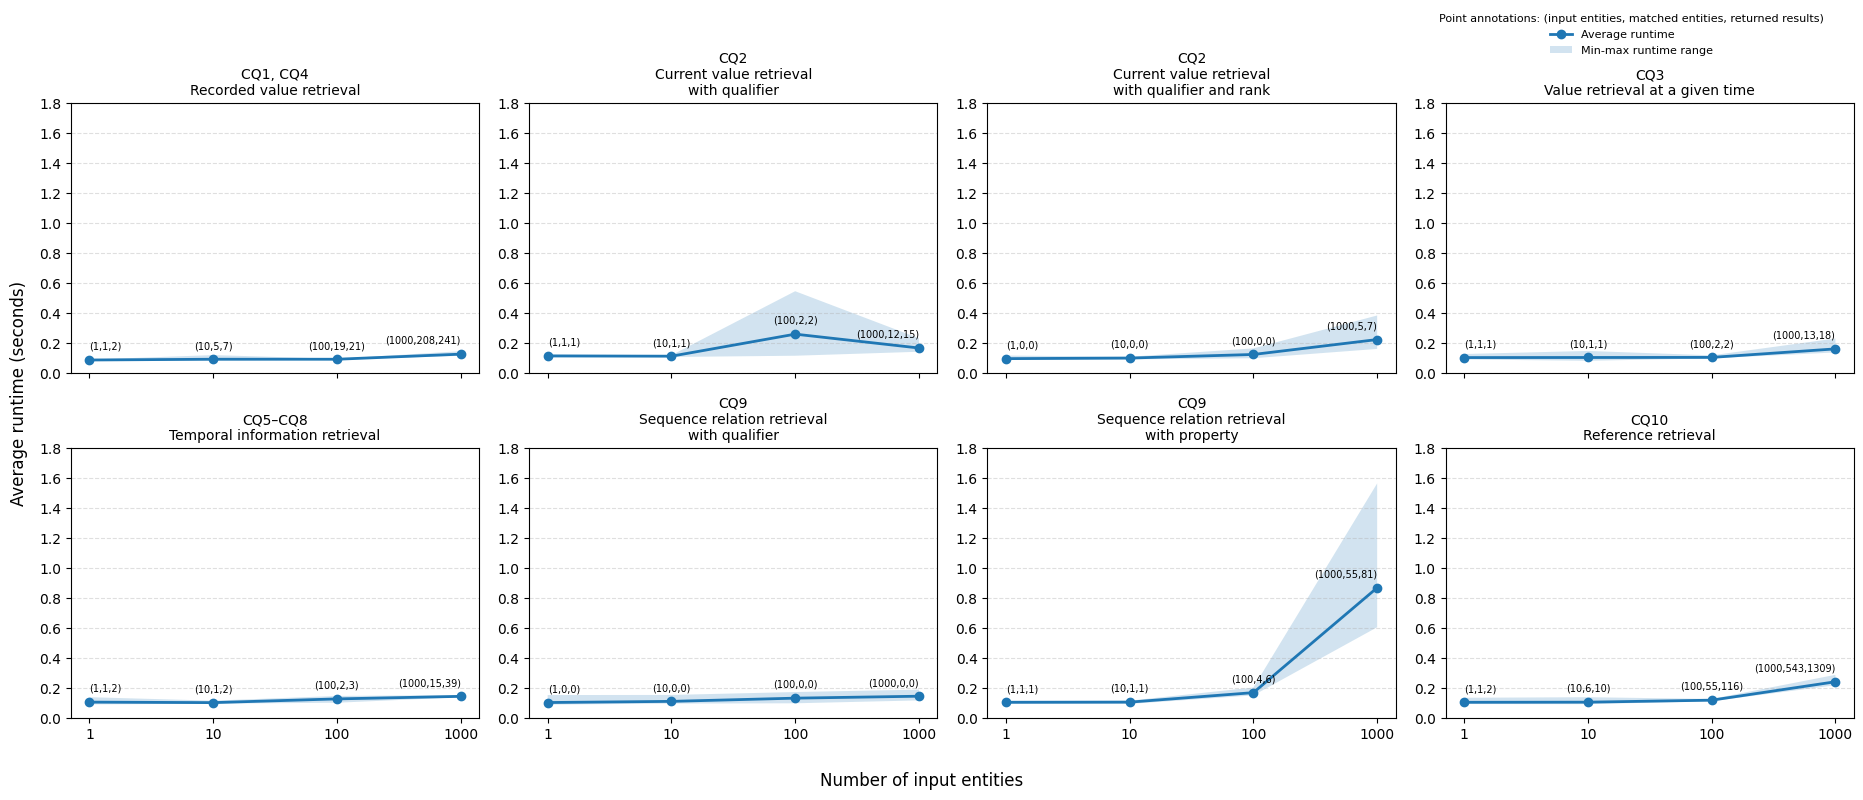

Saved: business_scalability0615.png
Common y-axis upper limit: 1.8
Y tick step: 0.2


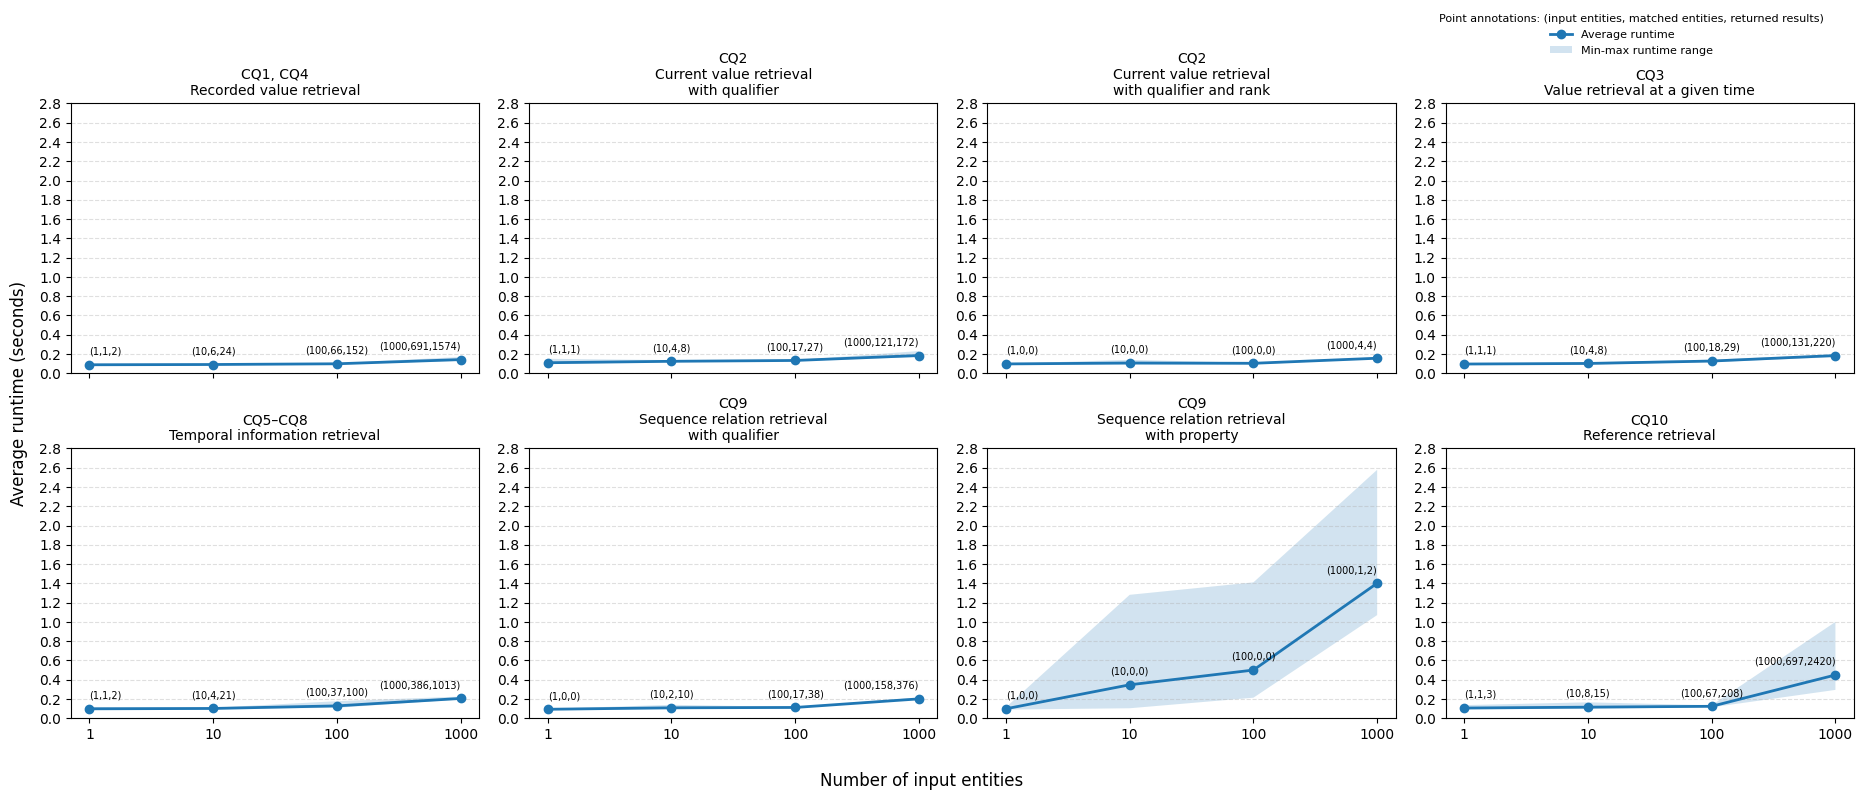

Saved: politician_scalability0615.png
Common y-axis upper limit: 2.8000000000000003
Y tick step: 0.2


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import math

# =========================
# 1. Read data
# =========================

file_path = "query_results_with_summary.xlsx"
df = pd.read_excel(file_path, sheet_name="average_summary")

# =========================
# 2. Keep needed data
# =========================

# Remove CQ4 because it shares the same retrieval structure as CQ1
# but mention CQ4 together with CQ1 in the subplot title
df = df[df["cq"] != "CQ4"].copy()

# Keep only business and politician
df = df[df["domain"].isin(["business", "politician"])].copy()

# =========================
# 3. Define template order and labels
# =========================

template_order = [
    "CQ1_recorded_value",
    "CQ2_current_value_qualifier",
    "CQ2_current_value_qualifier_rank",
    "CQ3_value_at_2024",
    "CQ5_CQ8_temporal_info",
    "CQ9_sequence_qualifier",
    "CQ9_sequence_property",
    "CQ10_reference",
]

template_label_map = {
    "CQ1_recorded_value": "CQ1, CQ4\nRecorded value retrieval",
    "CQ2_current_value_qualifier": "CQ2\nCurrent value retrieval\nwith qualifier",
    "CQ2_current_value_qualifier_rank": "CQ2\nCurrent value retrieval\nwith qualifier and rank",
    "CQ3_value_at_2024": "CQ3\nValue retrieval at a given time",
    "CQ5_CQ8_temporal_info": "CQ5–CQ8\nTemporal information retrieval",
    "CQ9_sequence_qualifier": "CQ9\nSequence relation retrieval\nwith qualifier",
    "CQ9_sequence_property": "CQ9\nSequence relation retrieval\nwith property",
    "CQ10_reference": "CQ10\nReference retrieval",
}

scale_order = [1, 10, 100, 1000]

df = df[df["template"].isin(template_order)].copy()
df["template_order"] = df["template"].map({t: i for i, t in enumerate(template_order)})
df["scale_order"] = df["scale"].map({s: i for i, s in enumerate(scale_order)})
df = df.sort_values(["domain", "template_order", "scale_order"])

# =========================
# 4. Plot function
# =========================

def plot_small_plots_with_range(domain_name, y_tick_step=0.2):
    domain_df = df[df["domain"] == domain_name].copy()

    # ---- determine one common y-axis range for all 8 subplots ----
    domain_ymax = domain_df["max_runtime_seconds"].max()

    # round up to nearest tick step
    upper_limit = math.ceil(domain_ymax / y_tick_step) * y_tick_step

    # give a little extra space for annotations
    upper_limit = upper_limit + y_tick_step

    fig, axes = plt.subplots(
        2, 4,
        figsize=(19, 8.1),
        sharex=True,
        sharey=True   # all subplots use the same y scale
    )

    axes = axes.flatten()

    x_positions = np.arange(len(scale_order))
    x_labels = [str(s) for s in scale_order]

    for ax, template in zip(axes, template_order):
        temp_df = domain_df[domain_df["template"] == template].copy()
        temp_df = temp_df.sort_values("scale_order")

        avg_values = []
        min_values = []
        max_values = []
        point_labels = []

        for scale in scale_order:
            row = temp_df[temp_df["scale"] == scale]

            if row.empty:
                avg_values.append(np.nan)
                min_values.append(np.nan)
                max_values.append(np.nan)
                point_labels.append("")
            else:
                avg_values.append(row["average_runtime_seconds"].iloc[0])
                min_values.append(row["min_runtime_seconds"].iloc[0])
                max_values.append(row["max_runtime_seconds"].iloc[0])

                input_entities = row["input_entities"].iloc[0]
                matched = row["matched_entities"].iloc[0]
                returned = row["returned_results"].iloc[0]
                
                point_labels.append(f"({int(input_entities)},{int(matched)},{int(returned)})"
                )

        avg_values = np.array(avg_values, dtype=float)
        min_values = np.array(min_values, dtype=float)
        max_values = np.array(max_values, dtype=float)

        # shaded min-max range
        ax.fill_between(
            x_positions,
            min_values,
            max_values,
            alpha=0.20
        )

        # average runtime line
        ax.plot(
            x_positions,
            avg_values,
            marker="o",
            linewidth=2
        )

        # annotate each point: (input, matched, returned)
        for i, (x, y, label) in enumerate(zip(x_positions, avg_values, point_labels)):
            if pd.notna(y) and label:
                
                # default
                x_offset = 0
                y_offset = 6
                ha = "center"
                
                # first point: move label slightly right
                if i == 0:
                   x_offset = 0
                   ha = "left"
                
                # last point: move label slightly left
                elif i == len(x_positions) - 1:
                     x_offset = 0
                     ha = "right"

                ax.annotate(
                    label,
                    (x, y),
                    textcoords="offset points",
                    xytext=(x_offset, y_offset),
                    ha=ha,
                    va="bottom",
                    fontsize=7,
                    clip_on=True
                )

        ax.set_title(template_label_map.get(template, template), fontsize=10)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)

        # same y-axis range for all subplots
        ax.set_ylim(0, upper_limit)

        # fixed y tick interval
        ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # show y tick labels on EVERY subplot
        ax.tick_params(axis='y', labelleft=True)

        ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    # main title
#    fig.suptitle(
#        f"Scalability  results by competency questions and query template in the {domain_name} domain",
#        fontsize=14
#    )

    fig.supxlabel("Number of input entities")
    fig.supylabel("Average runtime (seconds)")
    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="-",
            linewidth=2,
            label="Average runtime"
        ),
        Patch(
            alpha=0.20,
            label="Min-max runtime range"
        )
    ]
    
    fig.legend(
        handles=legend_handles,
        title="Point annotations: (input entities, matched entities, returned results)",
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        frameon=False,
        fontsize=8,
        title_fontsize=8
    )

    plt.tight_layout(rect=[0.01, 0.01, 1, 0.94])

    output_file = f"{domain_name}_scalability0615.png"
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_file)
    print("Common y-axis upper limit:", upper_limit)
    print("Y tick step:", y_tick_step)

# =========================
# 5. Draw figures
# =========================

plot_small_plots_with_range("business", y_tick_step=0.2)
plot_small_plots_with_range("politician", y_tick_step=0.2)